# **Random forest regression – main engine**

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

In [ ]:
# To track how well predictions work, all metrics -> dominance, MAPE/APE and benchmark performance
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    # Bounded training-validation set
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    # Previously optimized
    training_length = 1 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    # Rolling windows for single stock
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = RandomForestRegressor(n_estimators=100, max_depth=2)

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)
        
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        if mean_absolute_percentage_error(Test_Target, prediction) < mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        #print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
    
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()
    print(ticker)

ACN
ADBE
AMD
AKAM
APH
ADI
AAPL
AMAT
ANET
ADSK
AVGO
CDNS
CDW
CSCO
CTSH
GLW
DELL
ENPH
EPAM
FFIV
FICO
FSLR
FTNT
IT
GEN
GDDY
HPE
HPQ
IBM
INTC
INTU
JBL
KEYS
KLAC
LRCX
MCHP
MU
MSFT
MPWR
MSI
NTAP
NVDA
NXPI
ON
ORCL
PANW
PTC
QCOM
ROP
CRM
STX
NOW
SWKS
SMCI
SNPS
TEL
TDY
TER
TXN
TRMB
TYL
VRSN
WDC
WDAY
ZBRA


In [ ]:
# Average of dominances
means_prevalences = [np.mean(i) for i in performance_simple.values()]
np.mean(means_prevalences)

np.float64(1.0)

In [8]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [ ]:
# Average MAPE
print(np.mean(list(mean_performances.values())))

np.float64(1.6493936384009205)

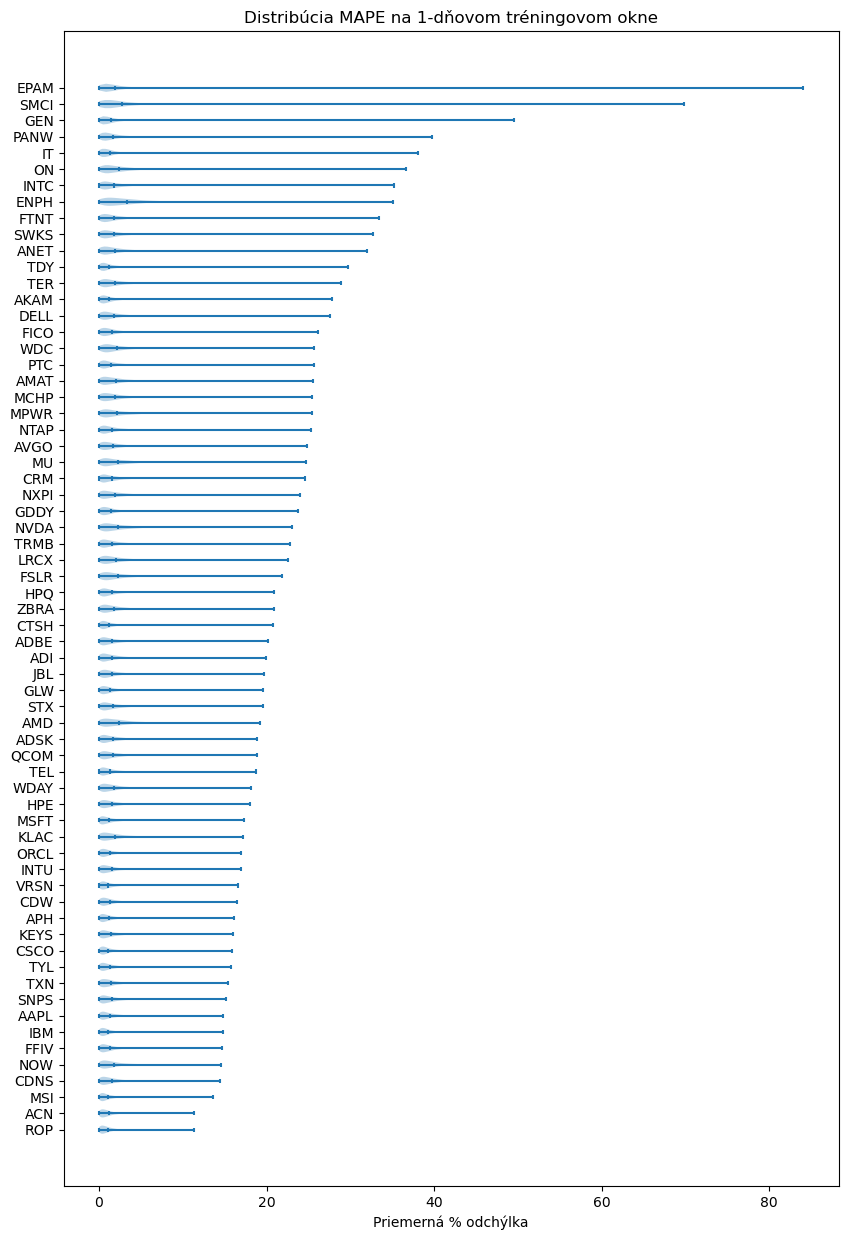

In [31]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

Focus on TOP/BOTTOM stocks.

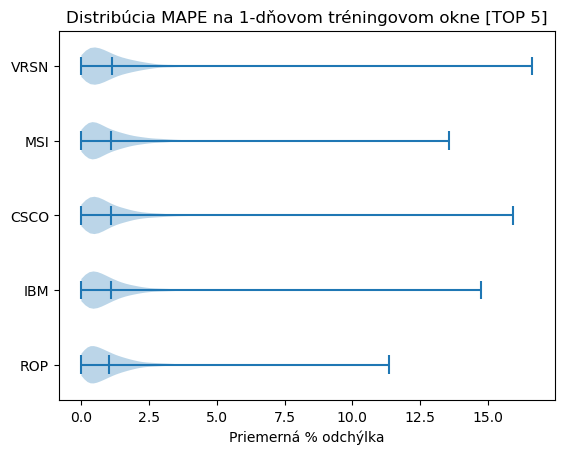

In [ ]:
plt.violinplot(performance_tracker[list(mean_performances.keys())[:5]], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 6), list(mean_performances.keys())[:5])

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne [TOP 5]")

plt.show()

In [13]:
# Pre porovnanie TOP/WORST 5
for ticker in ["VRSN", "CSCO", "IBM", "MSI", "ROP"][::-1]:
    print(ticker, np.mean(performance_tracker[ticker]))

ROP 1.0284909654358352
MSI 1.1089555881187876
IBM 1.0746729700619007
CSCO 1.1025344477893133
VRSN 1.1395875961481872


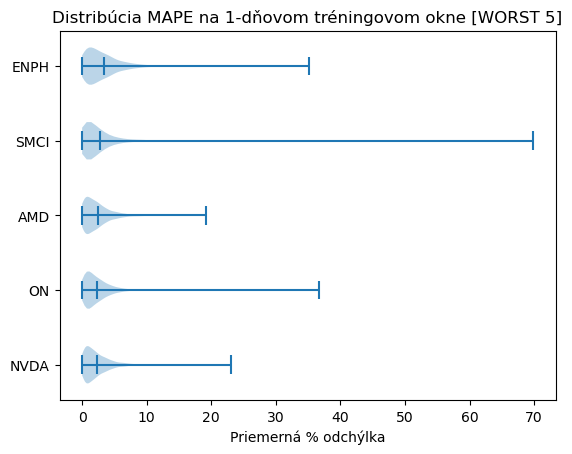

In [14]:
plt.violinplot(performance_tracker[list(mean_performances.keys())[-5:]], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 6), list(mean_performances.keys())[-5:])

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne [WORST 5]")

plt.show()

In [15]:
# Pre porovnanie TOP/WORST 5
for ticker in ["ENPH", "SMCI", "AMD", "NVDA", "ON"][::-1]:
    print(ticker, np.mean(performance_tracker[ticker]))

ON 2.372708603858515
NVDA 2.3304943682605734
AMD 2.4489461669964196
SMCI 2.7813045030840895
ENPH 3.3571655942773915
